#### STEP 1: Import the Required Libraries

In [24]:


# STEP 1: Import Required Libraries


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.4.6


#### STEP 2: Set Random Seed (Lab 8)

In [25]:


# STEP 2: Set Random Seed


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print("Random seed:", SEED)
print("No GPU detected. Training will use the CPU.")

Random seed: 42
No GPU detected. Training will use the CPU.


#### STEP 3: Check GPU

In [26]:

# STEP 3: Check GPU

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Found:")
    for gpu in gpus:
        print(gpu)
else:
    print("Running on CPU")

Running on CPU


#### STEP 4: Define Project Paths

In [27]:

# STEP 4: Define Project Paths

PROJECT_DIR = Path.cwd().parent

TRAIN_DIR = PROJECT_DIR / "dataset" / "train"
VALID_DIR = PROJECT_DIR / "dataset" / "validation"
TEST_DIR = PROJECT_DIR / "dataset" / "test"

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print(TRAIN_DIR)
print(VALID_DIR)
print(TEST_DIR)

c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\dataset\train
c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\dataset\validation
c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\dataset\test


#### STEP 5: Load the Dataset

In [28]:

# STEP 5: Load Dataset

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2072 files belonging to 2 classes.
Found 260 files belonging to 2 classes.
Found 259 files belonging to 2 classes.


#### STEP 6: Display Class Names

In [29]:

# STEP 6: Class Names

class_names = train_dataset.class_names

print(class_names)

['Tomato_Early_blight', 'Tomato_healthy']


#### STEP 7: Visualize the Dataset

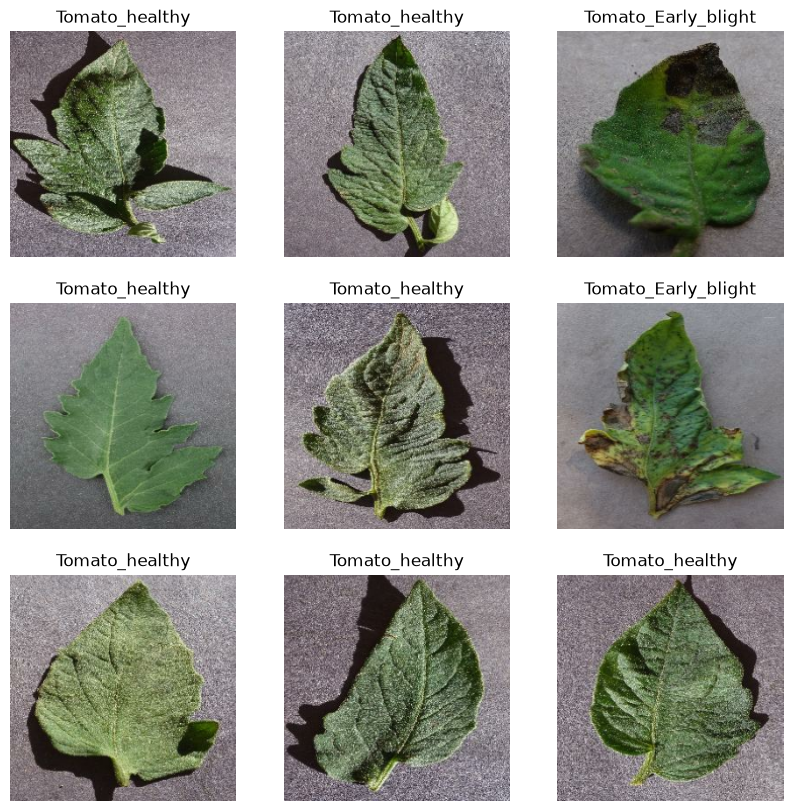

In [30]:

# STEP 7: Visualize Images

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

#### STEP 8: Optimize the Dataset

In [31]:

# STEP 8: Optimize Dataset Performance

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_dataset = (
    test_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

print("Datasets optimized successfully!")

Datasets optimized successfully!


#### STEP 9: Build the MobileNetV2 Model

In [32]:

# STEP 9: Load MobileNetV2 Base Model


base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


#### STEP 10: Build the Classifier

In [33]:

# STEP 10: Build Transfer Learning Model

model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.30),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.20),

    layers.Dense(
        2,
        activation="softmax"
    )

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### STEP 11: Compile the Model

In [34]:

# STEP 11: Compile Model

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]

)

print("Model compiled successfully!")

Model compiled successfully!


#### STEP 12: Configure Callbacks

In [35]:

# STEP 12: Configure Callbacks

checkpoint = ModelCheckpoint(

    filepath=MODEL_DIR / "tomato_disease_classifier.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    verbose=1

)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

#### STEP 13: Train the Model

In [36]:

# STEP 13: Train the Model

EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7128 - loss: 0.6067
Epoch 1: val_accuracy improved from None to 0.95385, saving model to c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\models\tomato_disease_classifier.keras

Epoch 1: finished saving model to c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\models\tomato_disease_classifier.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 636ms/step - accuracy: 0.7128 - loss: 0.6067 - val_accuracy: 0.9538 - val_loss: 0.2340 - learning_rate: 1.0000e-04
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9088 - loss: 0.2361
Epoch 2: val_accuracy improved from 0.95385 to 0.96538, saving model to c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\models\tomato_disease_classifier.keras

Epoch 2: finished saving model to c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\models\tomato_disease_classifier.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 591ms/step - accuracy: 0.9088 - loss: 0.2361 - val_accuracy: 0.9654 - val_loss: 0.1156 

#### STEP 14: Evaluate on the Test Set

In [37]:

# STEP 14: Evaluate Model

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 453ms/step - accuracy: 0.9923 - loss: 0.0266

Test Loss: 0.0266
Test Accuracy: 0.9923


#### STEP 15: Plot Training History

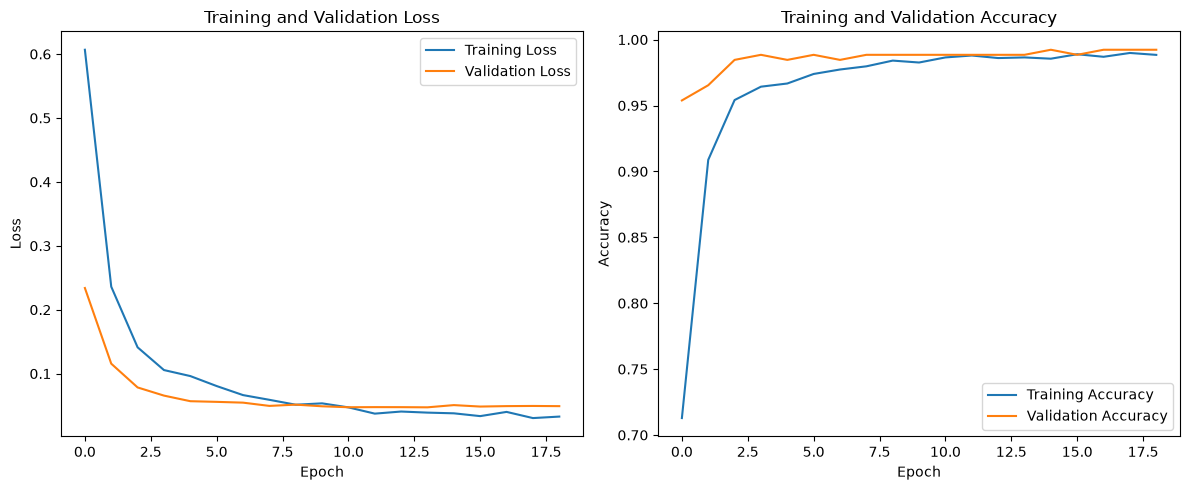

In [38]:

# STEP 15: Plot Training History

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

plt.show()

#### STEP 16: Save the Model

In [39]:

# STEP 16: Save Final Model

FINAL_MODEL = MODEL_DIR / "tomato_disease_classifier.keras"

model.save(FINAL_MODEL)

print("Model saved successfully!")
print(FINAL_MODEL)

Model saved successfully!
c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\models\tomato_disease_classifier.keras


#### STEP 17: Save the Training History

In [40]:

# STEP 17: Save Training History


history_df = pd.DataFrame(history.history)

history_df.to_csv(
    MODEL_DIR / "training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


#### STEP 18: Verify the Saved Model

In [41]:

# STEP 18: Verify Saved Model


loaded_model = tf.keras.models.load_model(FINAL_MODEL)

print("Saved model loaded successfully!")

loaded_model.summary()

Saved model loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,664 (10.49 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,454 (1.25 MB)